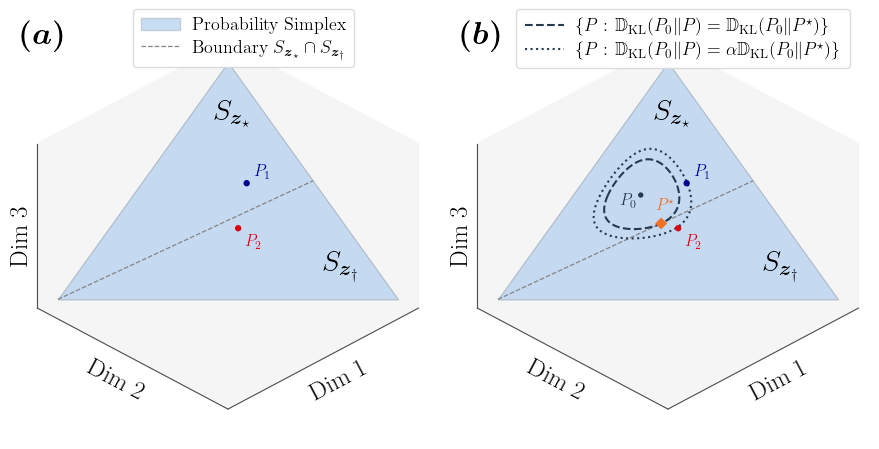

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d import proj3d

# Editable distributions and style settings.
P0 = np.array([0.36, 0.20, 0.44])
P1 = np.array([0.20, 0.31, 0.49])
P2 = np.array([0.32, 0.38, 0.30])
ALPHA = 1.7
LEGEND_SIZE = 13
PSTAR_COLOR = "#F37022"
CURVE_COLOR = "#263a50"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif"],
    "mathtext.fontset": "cm",
    "font.size": 18,
    "savefig.facecolor": "white",
    "text.usetex": True,
    "text.latex.preamble": (
        r"\usepackage{amsfonts}"
        r"\usepackage{amsmath}"
    ),
})


def kl(p, q):
    """Compute D_KL(p || q) along the last dimension."""
    return np.sum(p * np.log(p / q), axis=-1)


def kl_contour(p0, level, n=500):
    """Compute a KL level set by radial bisection in the simplex."""
    theta = np.linspace(0, 2 * np.pi, n)
    u = np.array([1., -1., 0.]) / np.sqrt(2)
    v = np.array([1., 1., -2.]) / np.sqrt(6)
    direction = np.cos(theta)[:, None] * u + np.sin(theta)[:, None] * v
    limits = np.full_like(direction, np.inf)
    np.divide(-p0, direction, out=limits, where=direction < 0)
    lo = np.zeros(n)
    hi = limits.min(axis=1) * (1 - 1e-12)
    for _ in range(65):
        mid = (lo + hi) / 2
        q = p0 + mid[:, None] * direction
        inside = kl(p0, q) < level
        lo = np.where(inside, mid, lo)
        hi = np.where(inside, hi, mid)
    return p0 + ((lo + hi) / 2)[:, None] * direction


def draw_simplex(ax, panel):
    ax.set_proj_type("ortho")
    ax.view_init(elev=32, azim=45)
    ax.set_box_aspect((1, 1, 0.72))
    ax.set(xlim=(-0.06, 1.06), ylim=(-0.06, 1.06), zlim=(-0.06, 1.06))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((0.96, 0.96, 0.96, 1))
        axis.line.set_color("0.3")
        axis.line.set_linewidth(0.8)

    ax.set_xlabel("Dim 1", labelpad=-8)
    ax.set_ylabel("Dim 2", labelpad=-8)
    # Place the vertical label inside the axes to prevent clipping.
    ax.set_zlabel("")
    ax.text2D(
        0.015, 0.49, "Dim 3", transform=ax.transAxes,
        rotation=90, ha="center", va="center", fontsize=18,
    )

    ax.add_collection3d(Poly3DCollection(
        [np.eye(3)], facecolors="#a8c9f0", edgecolors="#aebac8",
        linewidths=0.8, alpha=0.62, zorder=1,
    ))
    # The boundary satisfies sum(p)=1 and 2*p1+3*p2+p3=2.
    boundary = np.array([[1., 0., 0.], [0., 0.5, 0.5]])
    ax.plot(*boundary.T, color="0.52", lw=0.9, ls="--", zorder=3)
    ax.text(0.16, 0.08, 0.76, r"$S_{\boldsymbol{z}_\star}$",
            fontsize=21, zorder=5)
    ax.text(0.16, 0.72, 0.12, r"$S_{\boldsymbol{z}_\dagger}$",
            fontsize=21, zorder=5)
    ax.text2D(0.015, 1.01, panel, transform=ax.transAxes,
              fontsize=23, va="top")


def mark(ax, p, label, color, marker="o", offset=(5, 5), size=21):
    ax.scatter(*p, color=color, marker=marker, s=size,
               depthshade=False, edgecolors="none", zorder=6)
    return ax, p, label, color, offset


# Compute the KL projection onto p2=p3.
mean23 = (P0[1] + P0[2]) / 2
p_star = np.array([P0[0], mean23, mean23])
radius = kl(P0, p_star)

# A narrower figure and negative spacing bring the panels closer together.
fig = plt.figure(figsize=(10, 5))
axes = [fig.add_subplot(1, 2, i, projection="3d", computed_zorder=False)
        for i in (1, 2)]
fig.subplots_adjust(left=0.045, right=0.985, bottom=0.06,
                    top=0.89, wspace=-0.12)

labels = []
for ax, panel in zip(axes, ("$\\boldsymbol{(a)}$", "$\\boldsymbol{(b)}$")):
    draw_simplex(ax, panel)
    labels.append(mark(ax, P1, r"$P_1$", "#000091"))
    labels.append(mark(ax, P2, r"$P_2$", "#E1000F", offset=(5, -13)))

# Use identical legend positions, font sizes, and spacing in both panels.
# TeX struts give all legend entries the same minimum text height.
legend_options = dict(
    loc="upper center", bbox_to_anchor=(0.55, 1.035),
    fontsize=LEGEND_SIZE, framealpha=0.95, edgecolor="0.85",
    borderaxespad=0, borderpad=0.45, labelspacing=0.35,
    handlelength=2.2, handletextpad=0.65,
)
axes[0].legend(handles=[
    Patch(facecolor="#a8c9f0", edgecolor="#aebac8", alpha=0.62,
          label=r"\strut Probability Simplex"),
    Line2D([], [], color="0.52", lw=0.9, ls="--",
           label=r"\strut Boundary $S_{\boldsymbol{z}_\star}\cap S_{\boldsymbol{z}_\dagger}$"),
], **legend_options)

for level, style in ((radius, "--"), (ALPHA * radius, ":")):
    curve = kl_contour(P0, level)
    axes[1].plot(*curve.T, color=CURVE_COLOR, lw=1.5, ls=style, zorder=4)

labels.append(mark(axes[1], P0, r"$P_0$", CURVE_COLOR,
                   offset=(-15, -7), size=15))
# Match the diamond and its label using a distinct green color.
labels.append(mark(axes[1], p_star, r"$P^\star$", PSTAR_COLOR,
                   marker="D", offset=(-4, 10), size=37))

axes[1].legend(handles=[
    Line2D([], [], color=CURVE_COLOR, lw=1.5, ls="--", label=(
        r"\strut $\{P:\,\mathbb{D}_{\rm KL}(P_0\Vert P)="
        r"\mathbb{D}_{\rm KL}(P_0\Vert P^\star)\}$")),
    Line2D([], [], color=CURVE_COLOR, lw=1.5, ls=":", label=(
        r"\strut $\{P:\,\mathbb{D}_{\rm KL}(P_0\Vert P)="
        r"\alpha\mathbb{D}_{\rm KL}(P_0\Vert P^\star)\}$")),
], **legend_options)

# Add point labels after the layout and viewing angle are fixed.
fig.canvas.draw()
for ax, p, label, color, offset in labels:
    x, y, _ = proj3d.proj_transform(*p, ax.get_proj())
    ax.annotate(label, (x, y), xytext=offset, textcoords="offset points",
                color=color, fontsize=12, zorder=10)


fig.savefig("./figs/proposition1.pdf", bbox_inches="tight", pad_inches=0.12)
plt.show()
